# Voice recognition with OpenAI's Whisper model.
For this task, we will transcribe audio recorded from microphone using OpenAI's Whisper model. We will then visualize the audio data with Librosa and finally translate the transcription to English.

In [37]:
import torch
import sounddevice as sd
import soundfile as sf
import numpy as np
import ipywidgets as widgets
from IPython.display import display, Audio
from transformers import MarianMTModel, MarianTokenizer
import librosa
import librosa.display
import matplotlib.pyplot as plt
from transformers import WhisperProcessor, WhisperForConditionalGeneration


### Saving and loading audio file
Recording from microphone and saving to disk, then loading it back for processing.
You can stop recording at any time and after recording you can listen to the captured audio.

In [38]:
# Interactive microphone recording (Start/Stop buttons)
sr = 16000
channels = 1
save_path = "mic_recording.wav"

audio_chunks = []
stream = None
is_recording = False

status_out = widgets.Output()

start_btn = widgets.Button(description="Start Recording", button_style="success")
stop_btn = widgets.Button(description="Stop Recording", button_style="danger", disabled=True)


def audio_callback(indata, frames, time, status):
    if status:
        with status_out:
            print(status)
    # Copy chunk to avoid referencing mutable buffer
    audio_chunks.append(indata.copy())

def on_start_clicked(_):
    global stream, is_recording, audio_chunks
    if is_recording:
        return

    audio_chunks = []
    stream = sd.InputStream(
        samplerate=sr,
        channels=channels,
        dtype="float32",
        callback=audio_callback
    )
    stream.start()
    is_recording = True

    start_btn.disabled = True
    stop_btn.disabled = False

    with status_out:
        status_out.clear_output()
        print("Recording... Click 'Stop Recording' when finished.")


def on_stop_clicked(_):
    global stream, is_recording, y
    if not is_recording:
        return

    stream.stop()
    stream.close()
    stream = None
    is_recording = False

    start_btn.disabled = False
    stop_btn.disabled = True

    if len(audio_chunks) == 0:
        with status_out:
            print("No audio captured.")
        return

    y = np.concatenate(audio_chunks, axis=0).squeeze()  # shape: (samples,)
    sf.write(save_path, y, sr)

    with status_out:
        print(f"Recording stopped. Saved to {save_path}")
        print(f"Samples: {len(y)}, Duration: {len(y) / sr:.2f} s")
        display(Audio(y, rate=sr))


start_btn.on_click(on_start_clicked)
stop_btn.on_click(on_stop_clicked)

display(widgets.HBox([start_btn, stop_btn]))
display(status_out)



Output()

## Visualize the audio data
Visualizing the audio data with Librosa to understand it better. We use waveform and mel spectrogram to to see the structure of the audio signal.

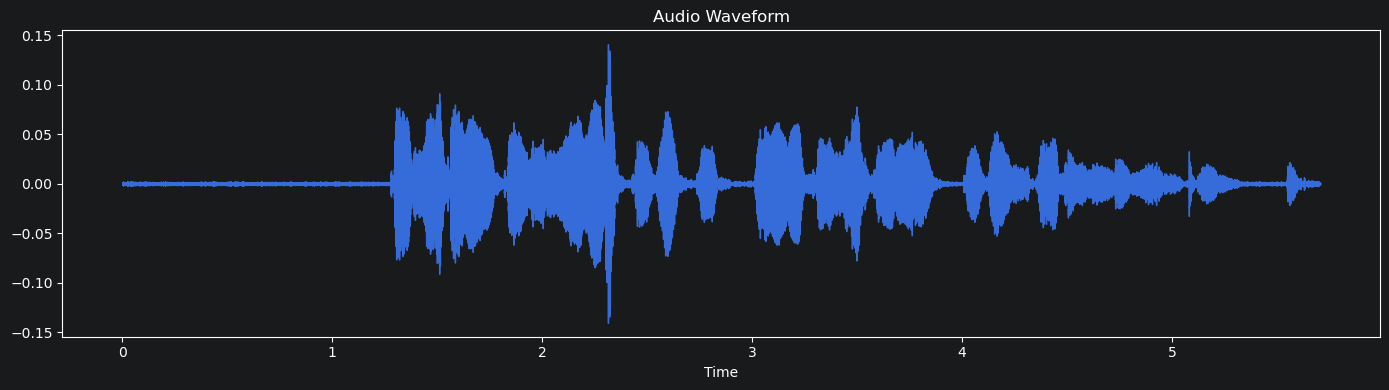

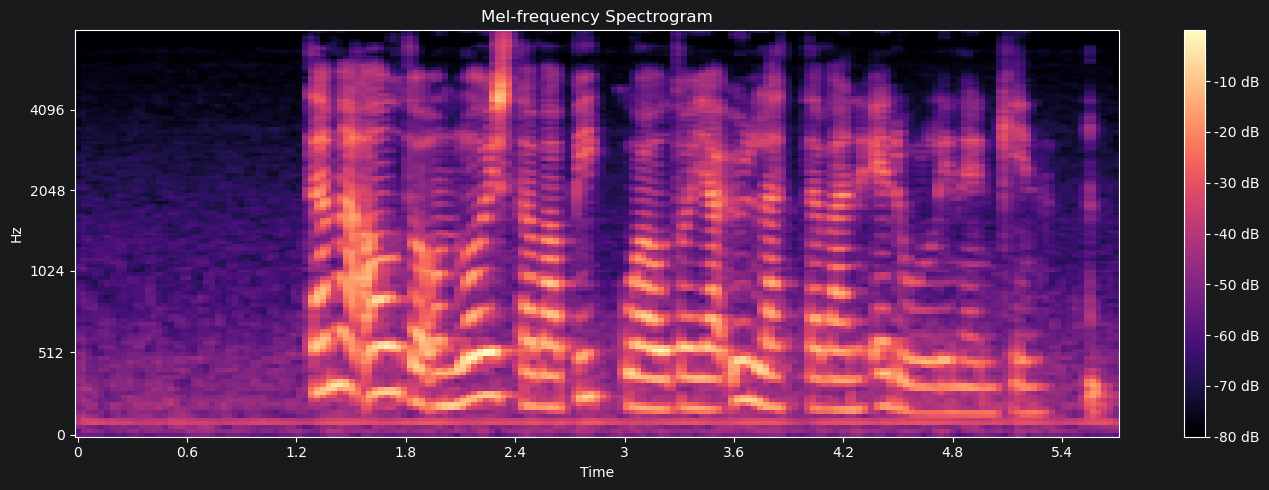

In [41]:
# Plot waveform
plt.figure(figsize=(14, 4))
librosa.display.waveshow(y, sr=sr)
plt.title('Audio Waveform')
plt.tight_layout()
plt.show()

# Create mel spectrogram
plt.figure(figsize=(14, 5))
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
S_dB = librosa.power_to_db(S, ref=np.max)
librosa.display.specshow(S_dB, y_axis='mel', x_axis='time', sr=sr)
plt.colorbar(format='%+2.0f dB')
plt.title('Mel-frequency Spectrogram')
plt.tight_layout()
plt.show()

## Transcription with Whisper
Using OpenAI's Whisper model, we transcribe the recorded audio. We initialize the model:
- Tiny
- Base
- Small
- Medium
- Large

We then process the audio file with the WhisperProcessor and generate the transcription. Finally, we decode the generated IDs to get the final transcription text.

In [42]:
# Initialize the model
model_size = "base"  # Options: tiny, base, small, medium, large
device = "cuda" if torch.cuda.is_available() else "cpu"
device = "mps" if torch.mps.is_available() else "cpu"
print(f"Using device: {device}")

# Load model and processor
print(f"Loading Whisper {model_size} model...")
model_name = f"openai/whisper-{model_size}"
processor = WhisperProcessor.from_pretrained(model_name)
model = WhisperForConditionalGeneration.from_pretrained(model_name).to(device)

# Set the language to Finnish
forced_decoder_ids = processor.get_decoder_prompt_ids(language="fi", task="transcribe")

# Process with WhisperProcessor
print("Processing audio...")
input_features = processor(
    y,
    sampling_rate=sr,
    return_tensors="pt"
).input_features.to(device)

# Generate the transcription
print("Generating transcription...")
with torch.no_grad():
    generated_ids = model.generate(
        input_features,
        language="fi",
        task="transcribe"
    )

# Decode the generated IDs
transcription = processor.batch_decode(
    generated_ids,
    skip_special_tokens=True
)[0]

print("\nFINNISH TRANSCRIPTION:")
print("="*50)
print(transcription)

Using device: mps
Loading Whisper base model...


Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

Processing audio...
Generating transcription...

FINNISH TRANSCRIPTION:
 Tämä auto on loistava pikkuaotoja yllättävän edullinenkin.


## Translation to English
Finally we translate the Finnish transcription to english using the same model.

In [43]:
# Set the task to translate
forced_decoder_ids_translate = processor.get_decoder_prompt_ids(language="fi", task="translate")

# Generate the translation
print("Generating English translation...")
with torch.no_grad():
    generated_ids = model.generate(
        input_features,
        language="en",
        task="transcribe"
    )

# Decode the generated IDs
translation = processor.batch_decode(
    generated_ids,
    skip_special_tokens=True
)[0]

print("\nENGLISH TRANSLATION:")
print("="*50)
print(translation)

Generating English translation...

ENGLISH TRANSLATION:
 This car is a small car and is designed for a car.
